<a href="https://colab.research.google.com/github/Pema-Codes/pytorch-learning/blob/main/02_pytorch_tensors.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Import necessary libraries

In [2]:
import torch  #imports main PyTorch library
from torch.utils.data import Dataset
from torchvision import datasets #provides access to popular datasets like FashionMNIST
from torchvision.transforms import v2 #for applying various image transformations
import matplotlib.pyplot as plt #plotting and visualizing data

# Loading Training data

This creates the training dataset. This is the data the model will look at over and over again to learn what a 'shirt' or 'shoe' looks like.

In [3]:
training_data = datasets.FashionMNIST(
    root="data", #creates a folder computer/Colab named "data" and drops the files inside it.
    train=True,  #indicates that this is the training split of the dataset
    download=True, #locally download if the dataset is not found
    transform=v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])
)   #the changes we wanna make to every single image as its downloaded.

100%|██████████| 26.4M/26.4M [00:01<00:00, 18.0MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 271kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.12MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 13.3MB/s]


#Loading Testing Data

In [4]:
test_data = datasets.FashionMNIST(
    root="data", #specifies same directory
    train=False, #PyTorch grabs the remaining 10,000 images that were set aside.
    download=True,
    transform=v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])
)

#Visualize a sample of the dataset


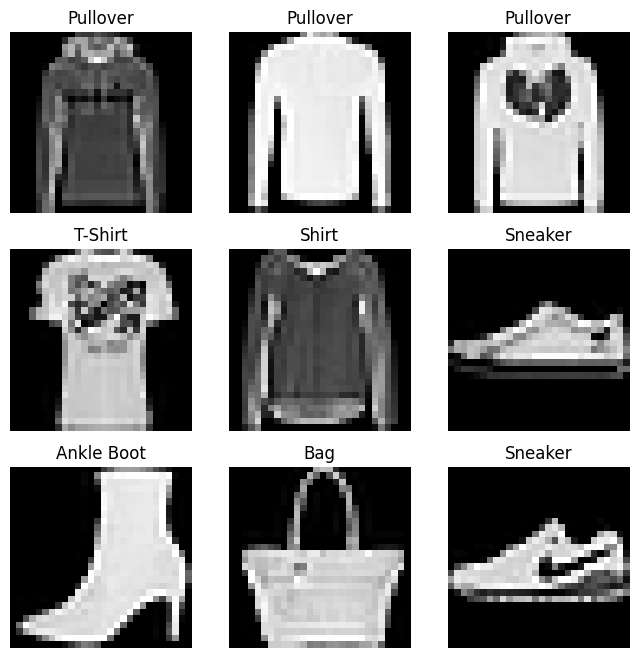

In [5]:
labels_map = {
    0: "T-Shirt",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle Boot",
}

figure = plt.figure(figsize=(8, 8))   #sets width and height of the figure in inches, new figure for plotting.
cols, rows = 3, 3 #defines the grid layout for subplots within the figure

for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(training_data), size=(1,)).item() #randomly selects an index from the training data.
    img, label = training_data[sample_idx] #Using the random index, it retrieves an image & its corresponding numerical label from the training_data dataset.
    figure.add_subplot(rows, cols, i) #adds a subplot to the figure
    plt.title(labels_map[label]) #sets the title of the current subplot to the human-readable name of item
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap="gray")
plt.show()

9 random images are visualized from the training data in a 3 by 3 grid. It uses a labels_map dictionary to convert the numerical labels (0-9) into human readable text (e.g., "T-Shirt","Trouser") and displays  these as titles above each image.  

#Preparing data for training with DataLoader

In [6]:
from torch.utils.data import DataLoader

train_dataloader = DataLoader(training_data, batch_size=64, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=64, shuffle=True)

#Iterate through the DataLoader

This code extracts a batch of data from the `DataLoader`, inspect its shape, and then visualize a single image and its corresponding label from that batch.

Feature batch shape: torch.Size([64, 1, 28, 28])
Labels batch shape: torch.Size([64])


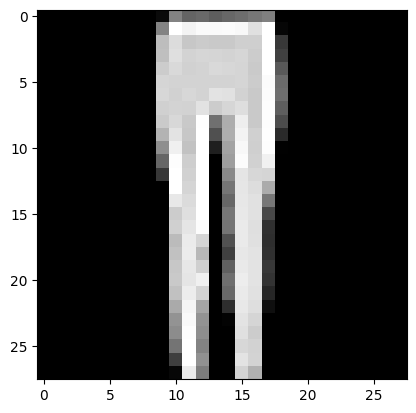

Label: 1


In [7]:
# Display image and label.
train_features, train_labels = next(iter(train_dataloader))
print(f"Feature batch shape: {train_features.size()}")
print(f"Labels batch shape: {train_labels.size()}")
img = train_features[0].squeeze()
label = train_labels[0]
plt.imshow(img, cmap="gray")
plt.show()
print(f"Label: {label}")